In [5]:
import os
import numpy as np
from tqdm import tqdm
import pandas as pd
import random
import sys
import json

# pytorch
sys.path.append('/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/utils')
sys.path.append('/home/agustin/phd/synthesis')

import utils.nifti_functions as nfc
import utils.functions as fc
import utils.util_freesurfer_segmentation as ufs
import utils.util as util

import prep_image as prep_image
import prep_histogram as prep_histogram
# from scipy.ndimage import zoom

from scipy.ndimage import gaussian_filter


In [6]:
df = pd.read_csv("/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/csv/train_data.csv")
df = df[df["paired"] == 0]

# count the subjects that have at least 2 modalities
df_subjects = df.groupby("sid").filter(lambda x: len(x) == 1)
print(f"Number of subjects with at least 2 modalities: {len(df_subjects['sid'].unique())}")

Number of subjects with at least 2 modalities: 511


In [7]:
def visualize_multiple_layers(image_list, figsize=(20, 20), name="", custom_disposition=(1,None)):
    imgs_list_2D = fc.cat_n_views_different_layers(
        image_list,
        view_layersoffset_list=[(2, 0), (2, -15), (1, 0), (0, 10), (0, 0)],
        axis=0,
        img_cropping=50,
        to_rgb=True,
    )
    fc.imgshow_list(imgs_list_2D, figsize=figsize, name=name, custom_disposition=custom_disposition)

def preprocess_image(src_img, src_seg):
    src_seg = ufs.merge_seg96_to_seg3(src_seg)
    src_img[src_seg == 0] = 0
    src_img = util.robust_normalize(src_img, strictly_positive=True, mask=src_seg > 0)

    return src_img, src_seg

def load_train_data(src_modality, src_res, tar_res, num_subjects=None):
    df = pd.read_csv("/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/csv/train_data.csv")
    df = df[df["paired"] == 1]

    df = df[(df["modality"] == src_modality) & ((df["resolution"] == src_res) | (df["resolution"] == tar_res))]

    if num_subjects is not None:
        unique_sids = df["sid"].unique()
        if num_subjects < len(unique_sids):
            selected_sids = random.sample(list(unique_sids), num_subjects)
            df = df[df["sid"].isin(selected_sids)]

    display(df)

    train_data = []
    for sid in df["sid"].unique():
        src_row = df[(df["sid"] == sid) & (df["modality"] == src_modality) & (df["resolution"] == src_res)].iloc[0]
        tar_row = df[(df["sid"] == sid) & (df["modality"] == src_modality) & (df["resolution"] == tar_res)].iloc[0]

        src_img, _ = nfc.load_nifti(src_row["org_img_path"])
        src_seg, _ = nfc.load_nifti(src_row["seg_supersynth_path"])
        tar_img, _ = nfc.load_nifti(tar_row["org_img_path"])
        tar_seg, _ = nfc.load_nifti(tar_row["seg_supersynth_path"])

        src_img, src_seg = preprocess_image(src_img, src_seg)
        tar_img, tar_seg = preprocess_image(tar_img, tar_seg)

        train_data.append({
            "src_img": src_img,
            "src_seg": src_seg,
            "tar_img": tar_img,
            "tar_seg": tar_seg
        })

    return train_data


def load_all_subject_data(df, sid, modalities, resolutions):
    df = df[df["sid"] == sid]

    subject_data = {}
    bar = tqdm(total=len(modalities) * len(resolutions), desc=f"Loading data for subject {sid}")
    for modality in modalities:
        subject_data[modality] = {}
        for resolution in resolutions:
            row = df[(df["modality"] == modality) & (df["resolution"] == resolution)].iloc[0]
            img, _ = nfc.load_nifti(row["org_img_path"])
            seg, _ = nfc.load_nifti(row["seg_supersynth_path"])
            img, seg = preprocess_image(img, seg)
            subject_data[modality][resolution] = {
                "img": img,
                "seg": seg
            }
            bar.update(1)
    bar.close




    return subject_data


In [4]:

df = pd.read_csv("/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/csv/train_data.csv")
df = df[df["paired"] == 1]
subject_data = load_all_subject_data(df, sid="S0006", modalities=["T1W", "T2W", "T2FLAIR"], resolutions=[0.1, 1.5, 3, 5, 7])
# subject_data = load_all_subject_data(df, sid="S0006", modalities=["T1W", "T2W",], resolutions=[0.1, 1.5, 3, 5, 7])
# load_train_data(src_modality="T1W", src_res=7, tar_res=3, num_subjects=1)

Loading data for subject S0006: 100%|██████████| 15/15 [02:51<00:00, 11.45s/it]


In [8]:
def load_mean_histograms_global_tissuewise(output_dir, modalitites=["T1W", "T2W", "T2FLAIR"], resolutions=[0.1, 1.5, 3, 5, 7]):
    mean_histograms_global_tw = {}
    for _modality in modalitites:
        mean_histograms_global_tw[_modality] = {}
        for _resolution in resolutions:
            mean_histograms_global_tw[_modality][_resolution] = np.load(os.path.join(output_dir, f"{_modality}_{_resolution}.npy"))
    return mean_histograms_global_tw

output_dir = "/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/postprocessing/histogram_matching/mean_histograms/global"
mean_histograms_global  = load_mean_histograms_global_tissuewise(output_dir, modalitites=["T1W", "T2W", "T2FLAIR"], resolutions=[0.1,1.5, 3, 5, 7]) 

# output_dir = "/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/postprocessing/histogram_matching/mean_histograms/tissuewise_3"
# mean_histograms_global_tw = load_mean_histograms_global_tissuewise(output_dir, modalitites=["T1W", "T2W", "T2FLAIR"], resolutions=[0.1,1.5, 3, 5, 7])

In [9]:
def load_corruption_parameters(modalities, resolutions_src_tar):
    corruption_params = {}
    parameters_path = "/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/preprocessing/tests/corrupt_image/best_corruption_parameters"
    for modality in modalities:
        corruption_params[modality] = {}
        for (scr_res, tar_res) in resolutions_src_tar:
            if scr_res not in corruption_params[modality]:
                corruption_params[modality][scr_res] = {}
            # Load the corruption parameters from the corresponding json file
            json_path = f"{parameters_path}/best_corruption_parameters_{modality}_{scr_res}T_{tar_res}T.json"
            with open(json_path, 'r') as f:
                df_params = json.load(f)
            corruption_params[modality][scr_res][tar_res] = df_params
    return corruption_params

corruption_params = load_corruption_parameters(modalities=["T1W", "T2W", "T2FLAIR"], 
                                               resolutions_src_tar=[(7, 0.1), (7, 1.5), (7, 3), (7, 5),
                                                                     (5, 0.1), (5, 1.5), (5, 3),
                                                                     (3, 0.1), (3, 1.5),
                                                                     (1.5, 0.1)])



In [10]:
def add_gaussian_noise(image, mask, sigma=0.05):
    noise = np.random.normal(0, sigma, image.shape)
    noisy_image = image + noise
    # clip to 0-1 range
    noisy_image = np.clip(noisy_image, 0, 1)
    noisy_image[mask == 0] = 0
    return noisy_image


def transform_image(
    src_img,
    src_seg,
    x_noise,
    x_sigma,
    x_power,
    histogram_reference,
    tissues_idx=[1, 2, 3],
    tissuewise_histogram_matching=True
):
    """
    Apply the complete transformation pipeline.
    """

    # # Histogram matching
    if tissuewise_histogram_matching:
        c_img_histmatched = prep_histogram.match_histogram_quantiles_tissuewise(
            src_img, 
            src_seg, 
            histogram_reference, 
            brain_mask=src_seg>0, 
            tissues_idx=[1, 2, 3])
    else:
        c_img_histmatched = prep_histogram.match_hist_with_reference(
            src_img,
            histogram_reference,
            mask=src_seg
        )


    # Noise
    c_img_noisy = add_gaussian_noise(
        c_img_histmatched,
        src_seg,
        x_noise
    )


    # Gaussian smoothing
    c_img_gaussian = gaussian_filter(
        c_img_noisy,
        sigma=x_sigma
    )

    # Power transform
    c_img_final = np.power(
        c_img_gaussian,
        x_power
    )

    return c_img_final




# visualize piramid

In [11]:
resolutions_src_tar=[(7, 0.1), (7, 1.5), (7, 3), (7, 5),
                    (5, 0.1), (5, 1.5), (5, 3),
                    (3, 0.1), (3, 1.5),
                    (1.5, 0.1)]

corrupted_imgs = {}
modlity = "T2FLAIR"
for i, (src_res, tar_res) in enumerate(resolutions_src_tar):
    if src_res not in corrupted_imgs:
        corrupted_imgs[src_res] = {}
    src_img = subject_data[modlity][src_res]["img"]
    src_seg = subject_data[modlity][src_res]["seg"]
    histogram_reference = mean_histograms_global[modlity][tar_res]
    # histogram_reference_tw = mean_histograms_global_tw[modlity][tar_res]

    params = corruption_params[modlity][src_res][tar_res]
    x_noise = params["x_noise"]
    x_sigma = params["x_sigma"]
    x_power = params["x_power"]

    
    x_noise = x_noise * 10 if src_res == 7 else x_noise * 5
    x_sigma = x_sigma * 1.4 if tar_res == 0.1 else x_sigma * 1.2 if tar_res in [1.5, 3] else x_sigma
    
    corrupted_img = transform_image(
        src_img,
        src_seg,
        x_noise,
        x_sigma,
        x_power,
        histogram_reference,
        tissues_idx=[1, 2, 3],
        tissuewise_histogram_matching=False
    )

    corrupted_imgs[src_res][tar_res] = corrupted_img




Preparing images for visualization: 100%|██████████| 25/25 [00:00<00:00, 3840.52it/s]


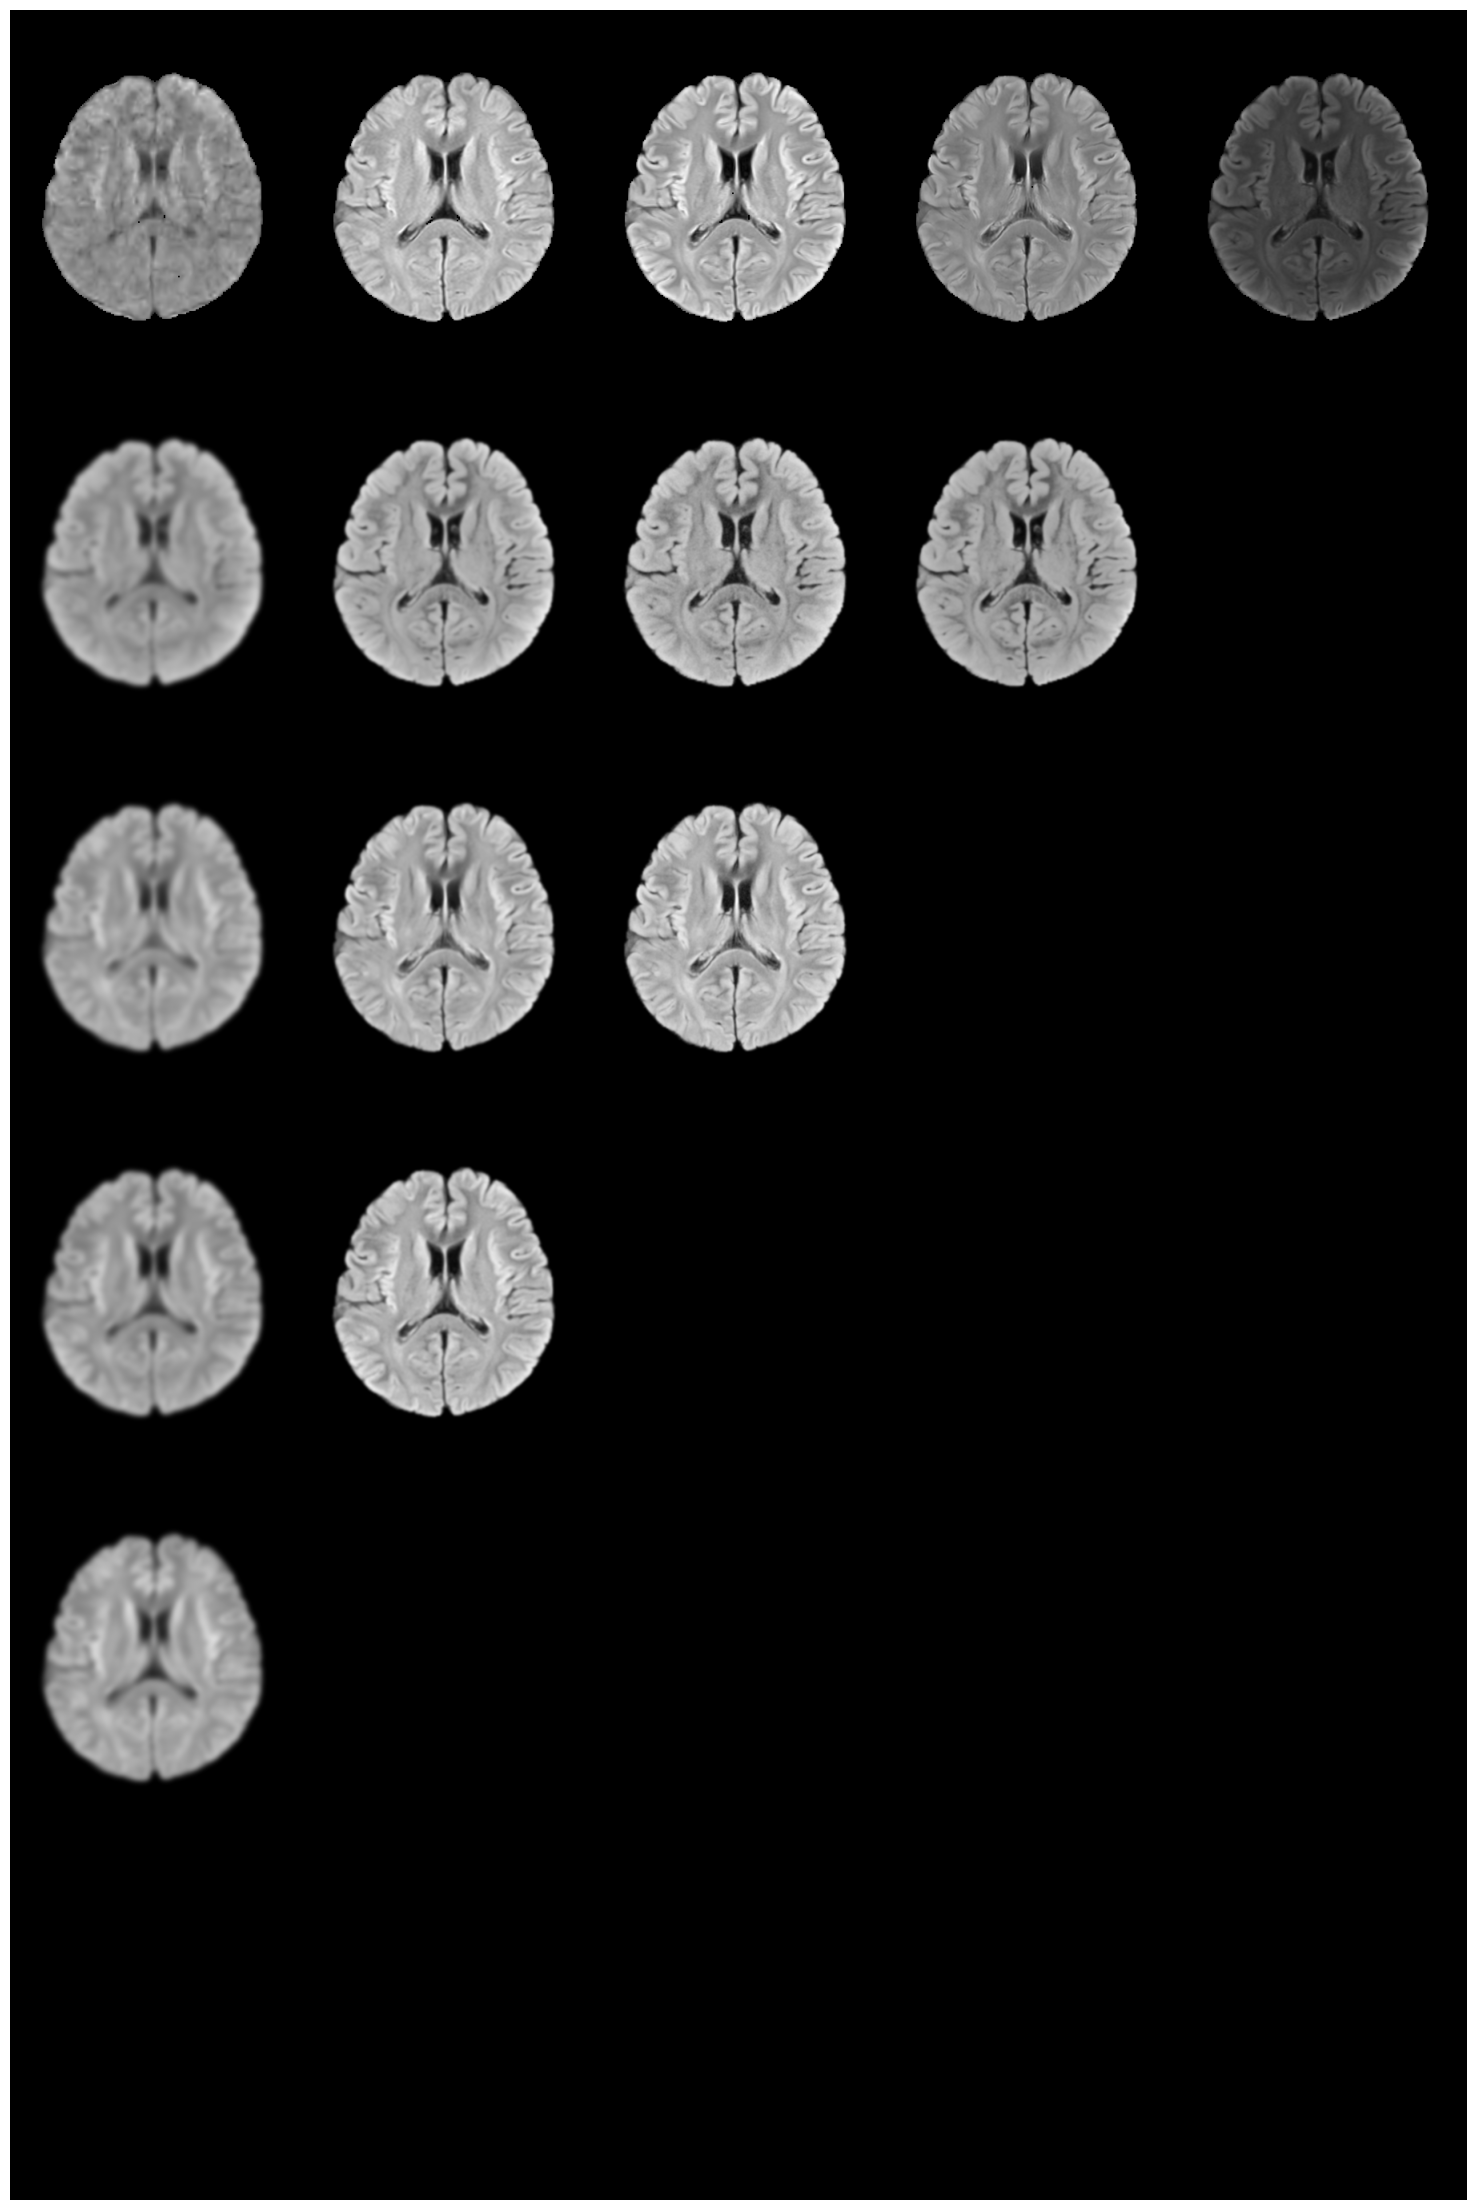

In [12]:
def prepare_images_for_visualization(img, slide):
    img = img[:,:,slide].T
    img = np.flipud(img)
    return img

_resolutions = [0.1, 1.5, 3, 5, 7]
middle_slide = subject_data[modlity][0.1]["img"].shape[2] // 2 - 10
imgs_to_visualize = [prepare_images_for_visualization(subject_data[modlity][src_res]["img"], middle_slide) for src_res in _resolutions]


bar = tqdm(total=len(_resolutions) * len(_resolutions), desc="Preparing images for visualization")
for i, src_res in enumerate(_resolutions[::-1]):
    for j, tar_res in enumerate(_resolutions):
        if tar_res < src_res:
            imgs_to_visualize.append(prepare_images_for_visualization(corrupted_imgs[src_res][tar_res], middle_slide))
            # print(f"Corrupted image from {src_res}T to {tar_res}T added to visualization.")
        else:
            imgs_to_visualize.append(np.zeros_like(imgs_to_visualize[0]))
            # imgs_to_visualize.append(prepare_images_for_visualization(np.zeros_like(subject_data[modlity][src_res]["img"]), middle_slide))

        bar.update(1)
bar.close()


custom_disposition = (None, len(_resolutions))
fc.imgshow_list(imgs_to_visualize, custom_disposition=custom_disposition, figsize=(30, 30))

In [32]:
sys.path.append("/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/utils")
import prep_image as prep_image
from scipy.ndimage import zoom


from autoencoder_declaration import AutoencoderPrediction
import torch


device_name = f"cuda:0"
device = torch.device(device_name)

autoencoder_chekpoint_path = "/home/agustin/phd/synthesis/tests/D3/maisi/understanding_vae/vae_weights/autoencoder_epoch273.pt"
autoencoder = AutoencoderPrediction(autoencoder_chekpoint_path, device, half=True)

# delete cuda
# image mean
c_manual = corrupted_imgs[7][5]
c_seg_manual = subject_data[modlity][7]["seg"]
# add noise
c_manual = add_gaussian_noise(c_manual, c_seg_manual, sigma=0.1)

# encode, add noise, decode
# prepared_image = prep_image.prepare_img(corrupted_imgs[7][5])
prepared_image = prep_image.prepare_img(subject_data[modlity][7]["img"])

latent_org = autoencoder.encode(prepared_image).detach().float().cpu().numpy().squeeze()

torch.cuda.empty_cache()


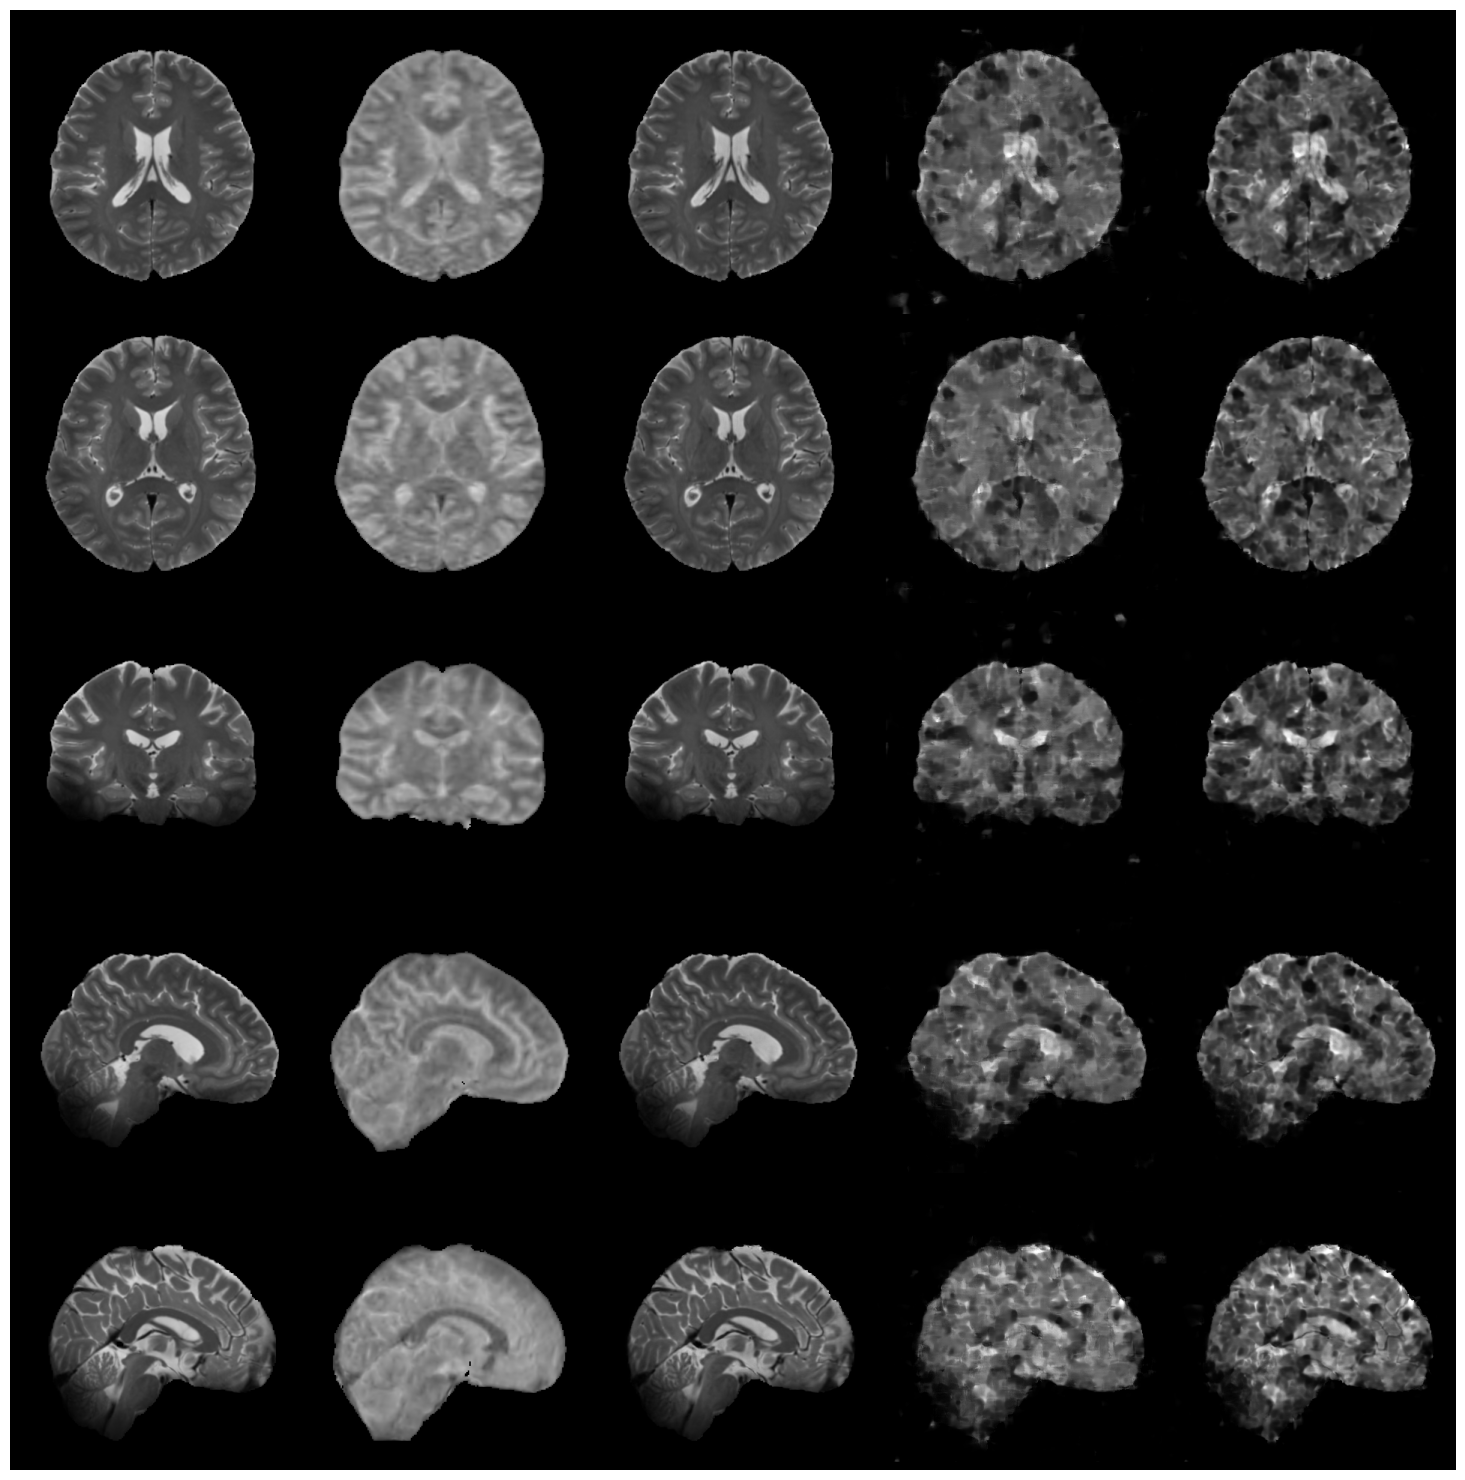

In [35]:




c_seg_manual = prep_image.prepare_img(c_seg_manual, normalize=False)
seg_small = zoom(c_seg_manual, (0.25, 0.25, 0.25), order=0)
mask = np.where(seg_small > 0, 1.0, 0.0)  # Create a binary mask where seg_small is greater than 0 
    
x_noise = 2
x_gaussian = 0.5
x_power = 0.5
noise = np.random.normal(0, x_noise, latent_org.shape)
# c_latent = latent_org + noise

def decode_latent(autoencoder, c_latent, device):
    c_manual_decoded = autoencoder.decode(torch.tensor(c_latent).to(device).half().unsqueeze(0)).cpu().numpy().squeeze()
    # clip to 0-1
    c_manual_decoded = np.clip(c_manual_decoded, 0, 1)
    c_manual_decoded = prep_image.postprocess_img(c_manual_decoded)
    return c_manual_decoded

c_manual_decoded_list = [decode_latent(autoencoder, latent_org, device)]
for i in range(latent_org.shape[0] -2):
    # add only in the first channel
    c_latent = latent_org.copy()

    if i == 0:
        c_latent += noise
        c_latent = gaussian_filter(c_latent, sigma=x_gaussian)
        # c_latent  = np.power(c_latent, x_power)
    else:
        c_latent[i-1] += noise[i-1] 
        c_latent[i-1] = gaussian_filter(c_latent[i-1], sigma=x_gaussian)
        # c_latent[i-1] = np.power(c_latent[i-1], x_power)


    
    c_manual_decoded_list.append(decode_latent(autoencoder, c_latent, device))
    # add the noise only to the latent_org values where the mask is 1
    # latent_org = latent_org + noise * mask



# visualize
# visualize_multiple_layers([corrupted_imgs[7][5], c_manual]+ c_manual_decoded_list, figsize=(20,20))
visualize_multiple_layers([subject_data[modlity][7]["img"], subject_data[modlity][0.1]["img"]]+ c_manual_decoded_list, figsize=(20,20))
# latent mean
torch.cuda.empty_cache()


In [15]:
c_image = transform_image(
    src_img=subject_data["T1W"][7]["img"],
    src_seg=subject_data["T1W"][7]["seg"],
    x_noise=corruption_params["T1W"][7][0.1]["x_noise"],
    x_sigma=corruption_params["T1W"][7][0.1]["x_sigma"],
    x_power=corruption_params["T1W"][7][0.1]["x_power"],
    histogram_reference=mean_histograms_global["T1W"][0.1]
)

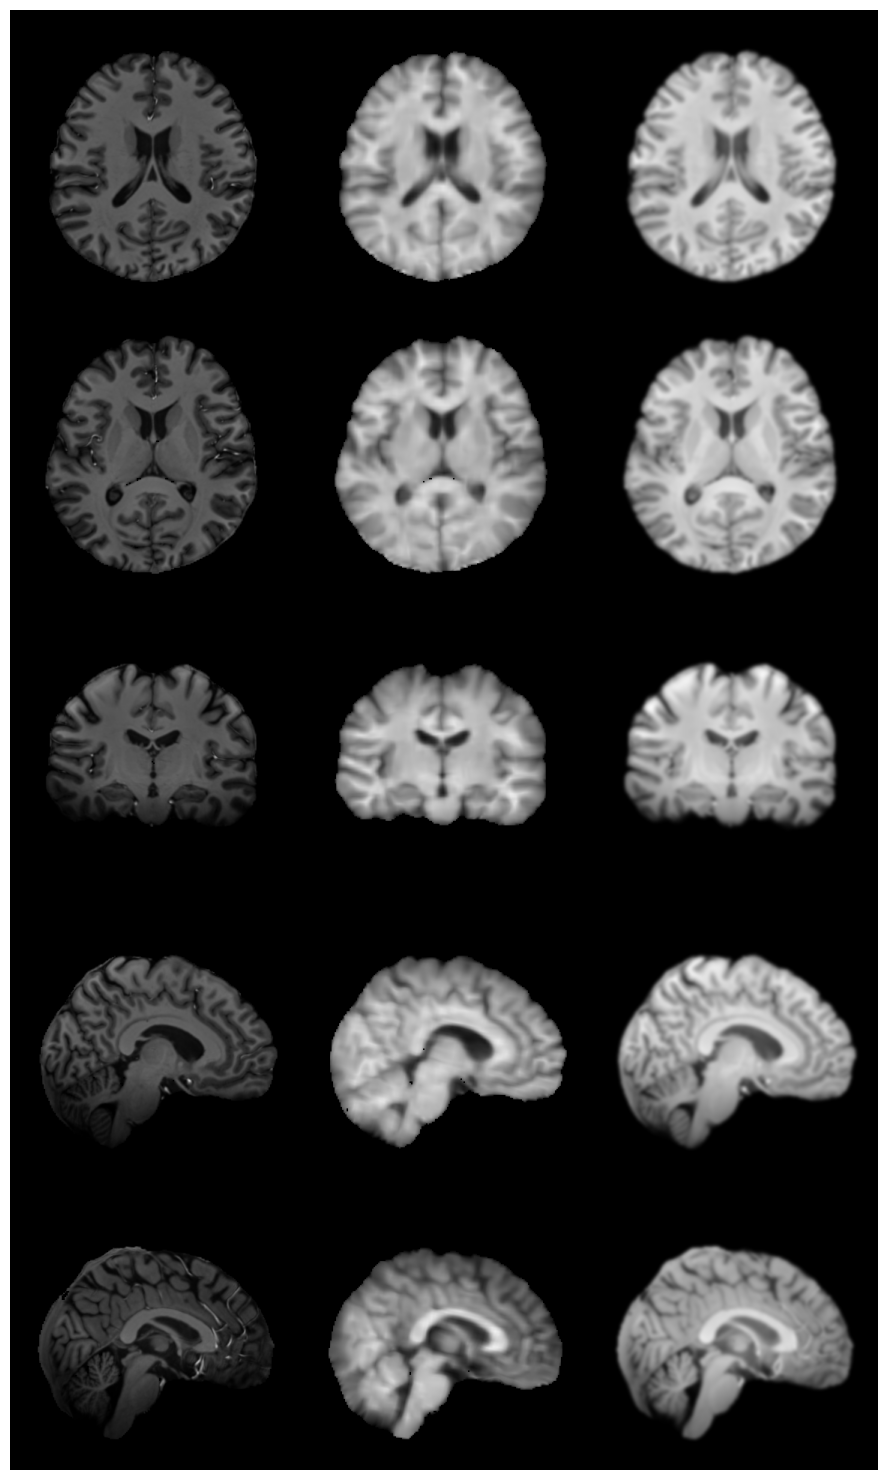

In [16]:
src_img = subject_data["T1W"][7]["img"]
tar_img = subject_data["T1W"][0.1]["img"]
visualize_multiple_layers([src_img, tar_img, c_image], figsize=(20, 20))


# Computation

In [149]:
df = pd.read_csv("/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/csv/train_data.csv")
df = df[df["paired"] == 1]

sid = df["sid"].unique()[0]
used_modality = "T1W"
src_res = 7
tar_res = 1.5
# base = "/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/synthsr"

src_row = df[(df["sid"] == sid) & (df["modality"] == used_modality) & (df["resolution"] == src_res)].iloc[0]
tar_row = df[(df["sid"] == sid) & (df["modality"] == used_modality) & (df["resolution"] == tar_res)].iloc[0]


src_img, aff = nfc.load_nifti(src_row["org_img_path"])
src_seg = nfc.load_nifti(src_row["seg_supersynth_path"])[0]

tar_img = nfc.load_nifti(tar_row["org_img_path"])[0]
tar_seg = nfc.load_nifti(tar_row["seg_supersynth_path"])[0]


src_seg = ufs.merge_seg96_to_seg3(src_seg)
src_img[src_seg == 0] = 0
src_img = util.robust_normalize(src_img, strictly_positive=True, mask=src_seg > 0)

tar_seg = ufs.merge_seg96_to_seg3(tar_seg)
tar_img[tar_seg == 0] = 0
tar_img = util.robust_normalize(tar_img, strictly_positive=True, mask=tar_seg > 0)

### Add noise

In [141]:
def add_gaussian_noise(image, mask, sigma=0.05):
    noise = np.random.normal(0, sigma, image.shape)
    noisy_image = image + noise
    # clip to 0-1 range
    noisy_image = np.clip(noisy_image, 0, 1)
    noisy_image[mask == 0] = 0
    return noisy_image

# c_img_noisy = add_gaussian_noise(src_img, src_seg,  0.05)
# visualize_multiple_layers([src_img, tar_img, c_img_noisy], figsize=(20, 20))


In [142]:
# c_img_gaussian = gaussian_filter(src_img, sigma=1.0)
# visualize_multiple_layers([src_img, tar_img, c_img_gaussian], figsize=(20, 20))


### Apply histogram matching

In [143]:


def load_mean_histograms_global_tissuewise(output_dir, modalitites=["T1W", "T2W", "T2FLAIR"], resolutions=[0.1, 1.5, 3, 5, 7]):
    mean_histograms_global_tw = {}
    for _modality in modalitites:
        mean_histograms_global_tw[_modality] = {}
        for _resolution in resolutions:
            mean_histograms_global_tw[_modality][_resolution] = np.load(os.path.join(output_dir, f"{_modality}_{_resolution}.npy"))
    return mean_histograms_global_tw

output_dir = "/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/postprocessing/histogram_matching/mean_histograms/global"
mean_histograms_global  = load_mean_histograms_global_tissuewise(output_dir, modalitites=["T1W", "T2W", "T2FLAIR"], resolutions=[1.5, 3, 5, 7]) 

output_dir = "/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/postprocessing/histogram_matching/mean_histograms/tissuewise_3"
mean_histograms_global_tw = load_mean_histograms_global_tissuewise(output_dir, modalitites=["T1W"], resolutions=[1.5, 3, 5, 7])

In [144]:

# c_img_histmatched = prep_histogram.match_hist_with_reference(src_img, mean_histograms_global[used_modality][tar_res], mask=src_seg)
# c_img_histmatched_tw = prep_histogram.match_histogram_quantiles_tissuewise(src_img, src_seg, mean_histograms_global_tw[used_modality][tar_res], brain_mask=src_seg>0, tissues_idx=[1, 2, 3])
# visualize_multiple_layers([src_img, tar_img, c_img_histmatched, c_img_histmatched_tw], figsize=(20, 20))


In [145]:
# plost histogram matching with tissuewise histograms
# for i, tissue_idx in enumerate([1, 2, 3]):
#     reference_quantiles_a = mean_histograms_global[modality][tar_res][i]
#     fc.plot_precomputed_hist(reference_quantiles_a, bins=1000, title="Histogram of tissue index {}".format(tissue_idx))


### All steps T1W

### From 7

### 3T

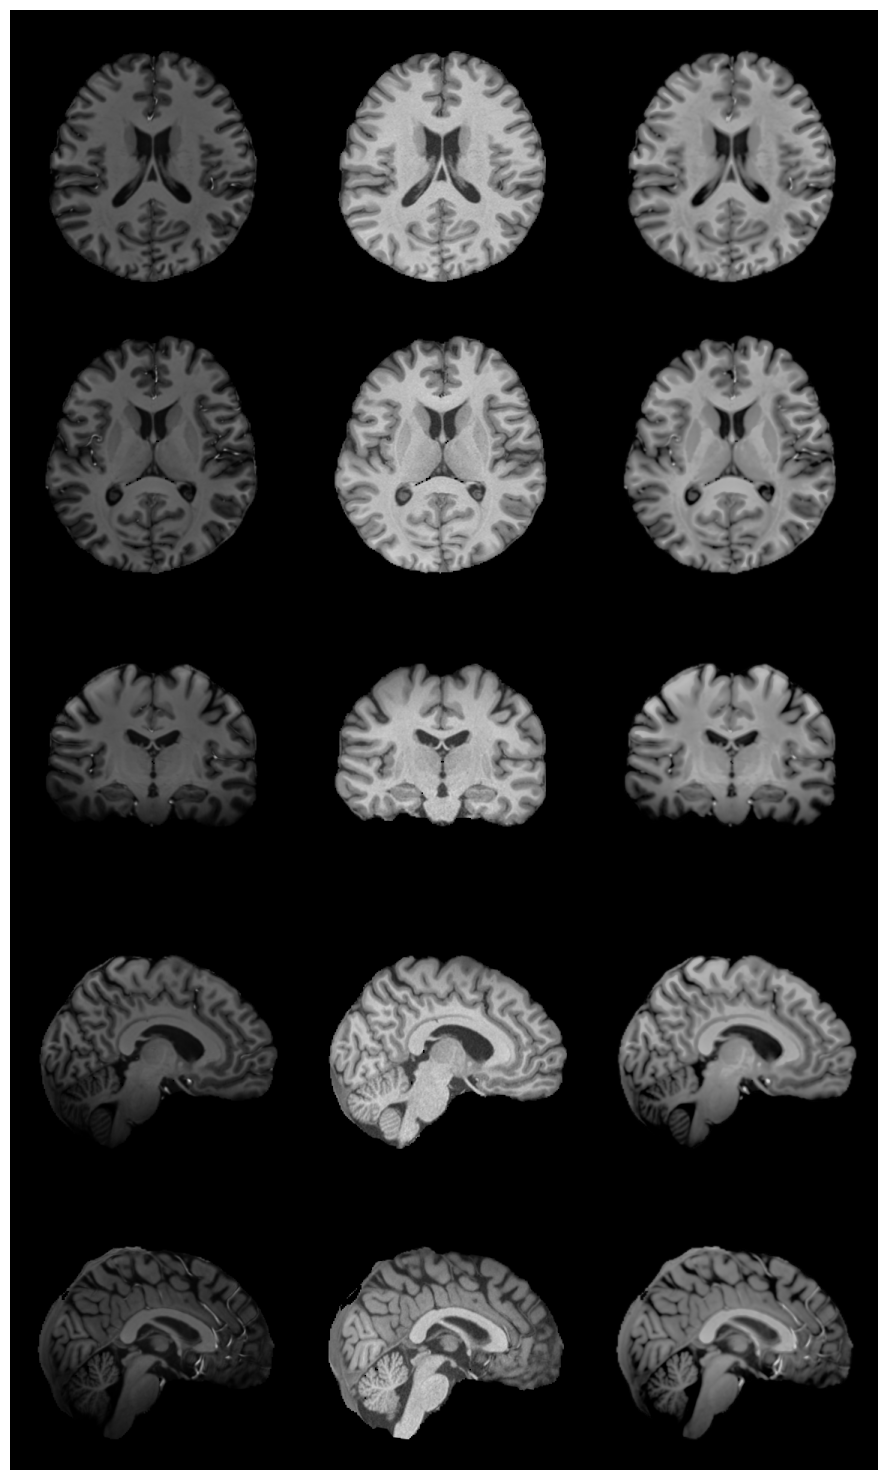

In [ ]:
#  best_mse=0.004190, noise=0.0162, sigma=0.6685, power=0.8162

# best_parameters = {}
# best_parameters[used_modality] = {}
# best_parameters[used_modality][src_res] = {}
# best_parameters[used_modality][src_res][tar_res] = {}

best_parameters_t1w_7_to_3 = {
    "noise": 0.0001,
    "sigma": 0.565,
    "power": 0.798
}

c_img_noisy = add_gaussian_noise(src_img, src_seg,  best_parameters_t1w_7_to_3["noise"])
c_img_gaussian = gaussian_filter(c_img_noisy, sigma=best_parameters_t1w_7_to_3["sigma"])
c_img_histmatched = prep_histogram.match_hist_with_reference(c_img_gaussian, mean_histograms_global[used_modality][tar_res], mask=src_seg)
# c_img_histmatched_tw = prep_histogram.match_histogram_quantiles_tissuewise(c_img_gaussian, src_seg, mean_histograms_global_tw[used_modality][tar_res], brain_mask=src_seg>0, tissues_idx=[1, 2, 3])

c_img_histmatched_power = np.power(c_img_histmatched, best_parameters_t1w_7_to_3["power"])
# c_img_histmatched_power = np.power(c_img_histmatched_tw, best_parameters_t1w_7_to_3["power"])


visualize_multiple_layers([src_img, tar_img,  c_img_histmatched_power], figsize=(20, 20))


### 1.5 T

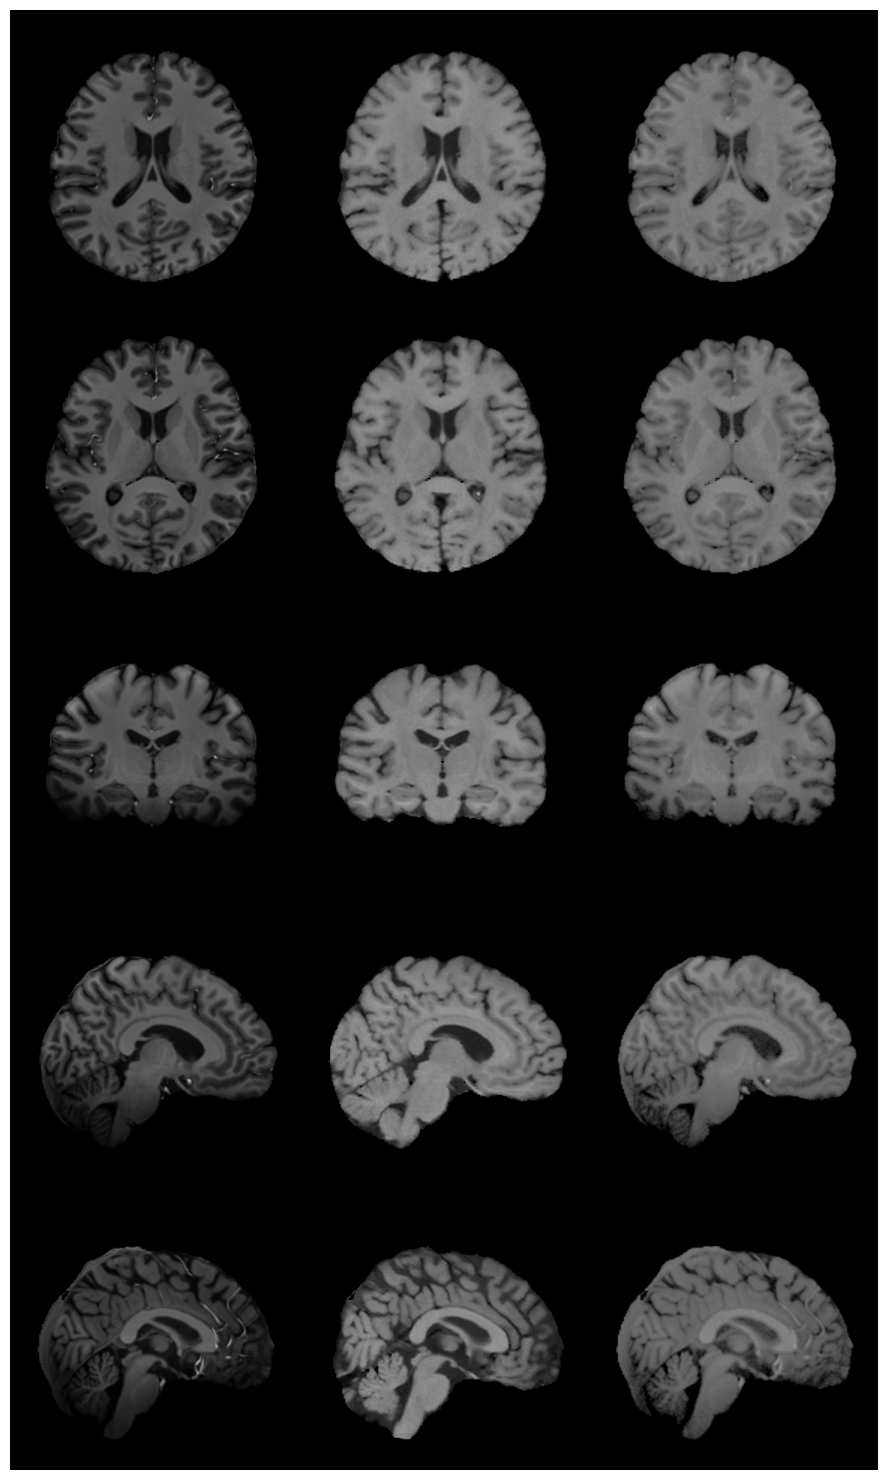

In [ ]:

# _src_img = np.power(src_img, 1.5)
best_parametes_t1w_7_to_15 = {
    "noise": 0.05,
    "sigma": 1.0,
    "power": 1
}
best_parametes_t1w_7_to_15 = {
    "noise": 0.205,
    "sigma": 0.866,
    "power": 0.817
}
c_img_noisy = add_gaussian_noise(src_img, src_seg,  best_parametes_t1w_7_to_15["noise"])
c_img_gaussian = gaussian_filter(c_img_noisy, sigma=best_parametes_t1w_7_to_15["sigma"])
# c_img_gaussian[src_seg == 1] = src_img[src_seg == 1]
c_img_histmatched = prep_histogram.match_hist_with_reference(c_img_gaussian, mean_histograms_global[used_modality][tar_res], mask=src_seg)
# c_img_histmatched = prep_histogram.match_histogram_quantiles_tissuewise(c_img_gaussian, src_seg, mean_histograms_global_tw[used_modality][tar_res], brain_mask=src_seg>0, tissues_idx=[1, 2, 3])

# # c_img_histmatched2 = prep_histogram.match_histogram_quantiles_tissuewise(src_img, src_seg, mean_histograms_global_tw[used_modality][tar_res], brain_mask=src_seg>0, tissues_idx=[1, 2, 3])
# c_img_histmatched2 = prep_histogram.match_hist_with_reference(src_img, mean_histograms_global[used_modality][tar_res], mask=src_seg)
# c_img_noisy2 = add_gaussian_noise(c_img_histmatched2, src_seg,  0.05)
# c_img_gaussian2 = gaussian_filter(c_img_noisy2, sigma=1.2)


c_img_gamma = np.power(c_img_histmatched, best_parametes_t1w_7_to_15["power"])
# c_img_gamma2 = np.power(c_img_gaussian2, 1.3)
# c_img_mean = (c_img_histmatched + c_img_gaussian2) / 2.0
# visualize_multiple_layers([src_img, tar_img, c_img_histmatched, c_img_gaussian2, c_img_gamma, c_img_gamma2, c_img_mean], figsize=(20, 20))

visualize_multiple_layers([src_img, tar_img, c_img_histmatched], figsize=(20, 20))
